<a href="https://colab.research.google.com/github/Mohamad-Selawy/Python/blob/master/Data%20Analysis/Level%203/Part_2_Visualization_with_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Data Visualization with Seaborn: Beyond Matplotlib

---

## Learning Objectives

By the end of this notebook, students should be able to:

- Understand why Seaborn is used in data analysis.
- Create professional statistical visualizations.
- Choose appropriate Seaborn charts for different analytical questions.
- Analyze distributions, relationships, and categorical comparisons.
- Interpret charts and communicate business insights.

## Setup and Data Loading

First, let's import the necessary libraries and load our dataset. We'll be using a Sales Forecasting dataset throughout this notebook to ground our learning in a real-world business context.

In [1]:
# Import necessary libraries
import pandas as pd # For data manipulation and analysis
import numpy as np # For numerical operations
import matplotlib.pyplot as plt # For basic plotting and customization (Seaborn is built on it)
import seaborn as sns # For advanced statistical data visualization
import kagglehub # For downloading datasets from Kaggle

# Configure Matplotlib for better aesthetics (optional, but good practice)
plt.style.use('ggplot') # Use ggplot style for plots
plt.rcParams['figure.figsize'] = (10, 6) # Set default figure size

print("Libraries loaded successfully!")

Libraries loaded successfully!


### Download and Load the Dataset

We'll use the 'sales-forecasting' dataset from KaggleHub. This dataset contains sales records that we can analyze to understand trends, patterns, and relationships.

In [2]:
# Download the dataset from KaggleHub
# This will download the dataset to a local directory.
path = kagglehub.dataset_download("rohitsahoo/sales-forecasting")

# Construct the full path to the CSV file. Assuming the CSV is directly in the downloaded path.
# You might need to adjust this if the CSV is in a subfolder within the downloaded archive.
# For this dataset, 'train.csv' is commonly found within the downloaded directory.
data_file_path = f"{path}/train.csv" # Adjust filename if different

# Load the dataset into a Pandas DataFrame
df = pd.read_csv(data_file_path)

print(f"Dataset loaded from: {data_file_path}")

Using Colab cache for faster access to the 'sales-forecasting' dataset.
Dataset loaded from: /kaggle/input/sales-forecasting/train.csv


### Initial Data Exploration

Let's get a first look at our data to understand its structure, types, and summary statistics. This is crucial before we start visualizing.

In [3]:
# Display the first 5 rows of the DataFrame
print("\n--- First 5 rows of the dataset ---")
display(df.head())

# Get a concise summary of the DataFrame, including data types and non-null values
print("\n--- DataFrame Info ---")
df.info()

# Generate descriptive statistics of the DataFrame's numerical columns
print("\n--- Descriptive Statistics ---")
display(df.describe())

# Display the shape of the DataFrame (number of rows, number of columns)
print(f"\n--- Dataset Shape: {df.shape} (rows, columns) ---")

# Display the column names
print("\n--- Column Names ---")
print(df.columns.tolist())


--- First 5 rows of the dataset ---


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680



--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000



--- Dataset Shape: (9800, 18) (rows, columns) ---

--- Column Names ---
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


### Dataset Introduction: Sales Forecasting

This dataset contains historical sales data, likely for various items across different stores and dates. It's a typical dataset used for sales forecasting, inventory management, and understanding consumer behavior. Key columns might include `date`, `store`, `item`, `sales`, etc.

Our goal with this dataset is to use visualization to uncover trends, identify strong/weak performing stores or items, understand sales distributions, and analyze relationships between different variables. This will help us derive actionable business insights.

## Review: Matplotlib Basics (10 Minutes)

Welcome back! In Notebook 1, you learned the fundamentals of Matplotlib, including how to create basic plots like line charts, scatter plots, and bar charts. You also covered customizing titles, labels, and plot styles. While Matplotlib is incredibly powerful and forms the foundation for many Python plotting libraries, it can sometimes be verbose for statistical plots.

### Why Seaborn? How it Extends Matplotlib

Matplotlib gives you precise control over every element of a plot, making it excellent for highly customized static visualizations. However, when you need to create common statistical plots or work with Pandas DataFrames, Matplotlib can require a lot of code.

**Seaborn** was created to simplify the process of creating informative and attractive statistical graphics. It's built on top of Matplotlib and integrates beautifully with Pandas data structures. Think of it as a high-level API for Matplotlib, providing a more convenient interface for complex visualizations, especially those involving multiple variables or statistical estimations.

### When to Prefer Seaborn vs. Matplotlib

*   **Prefer Seaborn when:**
    *   You need to visualize statistical relationships between variables.
    *   You're working directly with Pandas DataFrames and want to easily map columns to visual properties (like color, size, shape).
    *   You want aesthetically pleasing default plots with minimal code.
    *   You're exploring distributions, relationships, or categorical comparisons.

*   **Matplotlib is still useful when:**
    *   You need fine-grained control over every aspect of your plot (e.g., custom annotations, complex layouts).
    *   You're creating highly specialized or non-standard plots.
    *   You need to embed plots into GUI applications.
    *   You're working with data that isn't easily structured into a DataFrame.

In essence, Seaborn streamlines the creation of common statistical plots, while Matplotlib provides the underlying canvas and tools for ultimate customization. Together, they form a formidable duo for data visualization in Python.

### Data Preprocessing: Date Columns

Before diving into visualizations, it's good practice to ensure our data types are correct. We noticed that 'Order Date' and 'Ship Date' are currently `object` types. For any time-based analysis or plotting, these need to be converted to `datetime` objects.

In [4]:
# Convert 'Order Date' and 'Ship Date' to datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

# Verify the conversion
print("\n--- DataFrame Info after Date Conversion ---")
df.info()

# Display the first few rows to show updated date format
print("\n--- First 5 rows with converted dates ---")
display(df.head())


--- DataFrame Info after Date Conversion ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-nu

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## Section 1 — Introduction to Seaborn (20 Minutes)

Now that our data is ready, let's explore Seaborn! As we discussed, Seaborn is a powerful Python data visualization library built on Matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics.

### What is Seaborn and Why is it Popular?

**Seaborn** is essentially a wrapper around Matplotlib, designed to make creating complex statistical plots much easier and visually appealing. Here's why it's so popular among data analysts:

1.  **Aesthetic Defaults:** Seaborn comes with beautiful default styles and color palettes that make your plots look professional without much effort.
2.  **High-Level Interface:** It simplifies the process of plotting by abstracting away much of the underlying Matplotlib complexity. You often need fewer lines of code to create sophisticated plots.
3.  **Statistical Plotting:** Seaborn specializes in visualizing statistical relationships, distributions, and comparisons. It's built for understanding data patterns.
4.  **Pandas Integration:** It works seamlessly with Pandas DataFrames. You can directly pass DataFrame columns as arguments to plotting functions, making data exploration intuitive.
5.  **Multi-Variate Visualization:** Seaborn makes it easier to explore relationships between multiple variables using concepts like `hue`, `size`, and `style` to encode additional information.

### Built-in Themes and Color Palettes

Seaborn provides several built-in themes to control the aesthetic style of your plots, such as `'darkgrid'`, `'whitegrid'`, `'dark'`, `'white'`, and `'ticks'`. These themes automatically adjust things like background color, grid lines, and axis ticks.

It also offers a rich variety of color palettes, which are crucial for effective data storytelling. You can choose from qualitative, sequential, and diverging palettes, depending on the nature of your data.

Let's see some basic examples to demonstrate Seaborn's default style and theme capabilities.

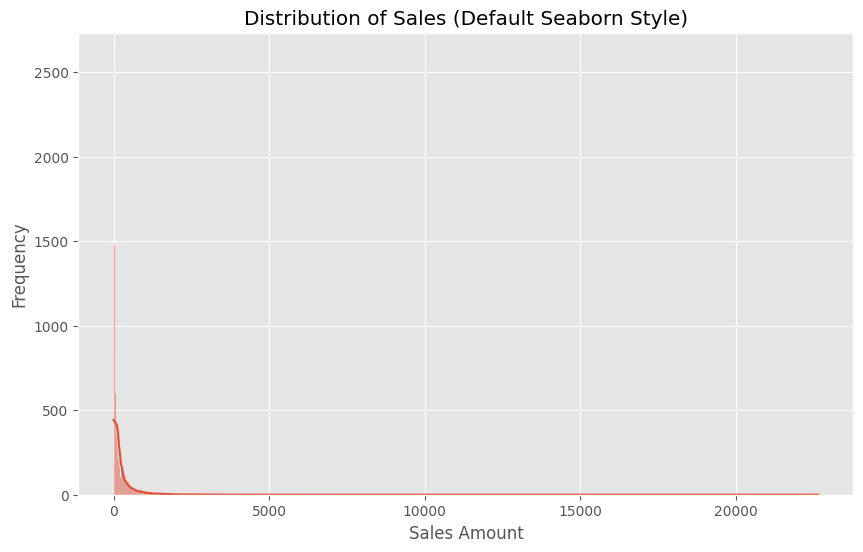

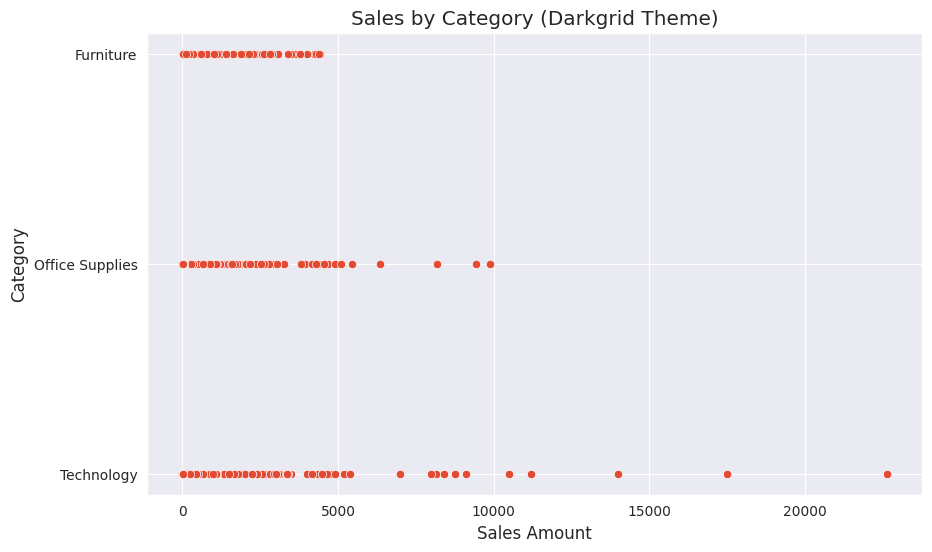

In [5]:
# Example 1: Demonstrate default Seaborn style with a simple distribution plot
# We'll use the 'Sales' column to see its distribution.

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Sales', kde=True) # kde=True adds a Kernel Density Estimate line
plt.title('Distribution of Sales (Default Seaborn Style)')
plt.xlabel('Sales Amount')
plt.ylabel('Frequency')
plt.show()

# Interpretation:
# This histogram shows the frequency of different sales amounts. The KDE curve helps to visualize the shape of the distribution.
# We can observe that most sales are concentrated at lower values, with a long tail extending to higher sales amounts, indicating a skewed distribution.

# Business Insight:
# This highly skewed distribution suggests that a large portion of our sales come from many smaller transactions, while a few transactions contribute significantly higher sales. This insight is crucial for sales strategies, marketing, and inventory management, as different approaches might be needed for low-value vs. high-value transactions.


# Example 2: Changing Seaborn theme
# Let's try another theme like 'darkgrid'

sns.set_style('darkgrid') # Set the theme to 'darkgrid'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sales', y='Category') # A simple scatter plot to show categories vs sales
plt.title('Sales by Category (Darkgrid Theme)')
plt.xlabel('Sales Amount')
plt.ylabel('Category')
plt.show()

# Interpretation:
# This scatter plot displays individual sales values for each product category. By changing the style to 'darkgrid', the visual appearance of the plot has changed, particularly the background and gridlines.

# Business Insight:
# While the specific insights from this plot would require more in-depth analysis (which we'll do later), this example primarily showcases how easy it is to change the overall aesthetic of your plots using Seaborn's `set_style()` function, giving them a different professional look instantly.

#### **Best Practice:** Always reset style after demonstrating different themes, or set a consistent theme at the beginning of your notebook.

```python
# Reset to default or preferred style for consistency throughout the notebook
sns.set_style('whitegrid') # A common and clean style for presentations
```

In [6]:
# Reset to default or preferred style for consistency throughout the notebook
sns.set_style('whitegrid') # A common and clean style for presentations
print("Seaborn style reset to 'whitegrid'.")

Seaborn style reset to 'whitegrid'.


## Section 2 — Essential Seaborn Charts (80 Minutes)

In this section, we will explore some of the most commonly used and powerful Seaborn charts. For each chart, we will cover its purpose, when to use it (and when not to), a business example, fully commented Python code, important parameters, interpretation, and a business insight derived from the visualization.

### 1. Scatter Plot (`sns.scatterplot()`)

*   **Purpose:** To visualize the relationship between two continuous variables.
*   **When to Use It:**
    *   To identify correlations or trends between two quantitative variables.
    *   To detect outliers or clusters in the data.
    *   When you have a moderate number of data points. For very large datasets, alternatives like hexbin plots or 2D histograms might be more suitable due to overplotting.
*   **When Not to Use It:**
    *   For visualizing categorical data or a single variable's distribution.
    *   When dealing with time series, a line plot is usually more appropriate.
*   **Business Example:** Analyzing the relationship between `Sales` and `Profit` (if available, otherwise we will use `Sales` vs `Quantity` or similar proxies, or focus on a single variable's spread per category if two continuous variables aren't directly available for strong correlation example in this specific dataset without aggregation). Given our dataset, we can analyze `Sales` across different product `Category` or `Sub-Category` to see the spread.

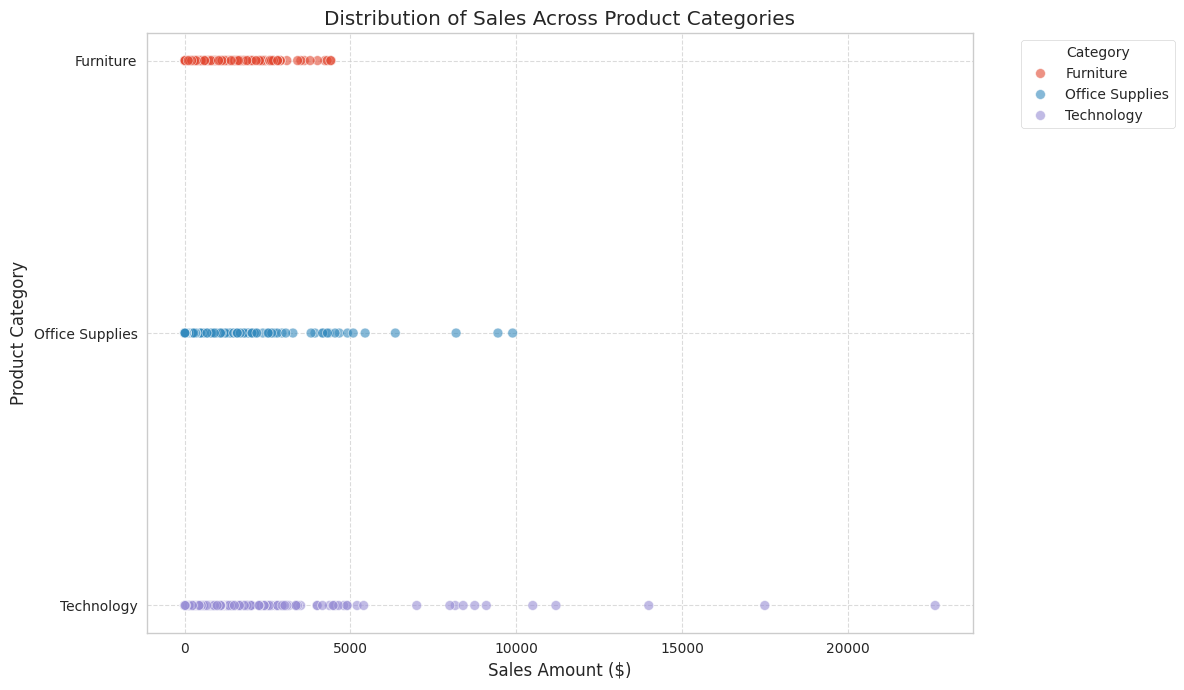

In [7]:
# Business Example: Sales distribution across Categories
# Let's visualize the distribution of sales values for each product category.
# While not a direct correlation, it helps understand the range of sales within each category.

plt.figure(figsize=(12, 7))
# Create a scatter plot using Seaborn
# x='Sales': Specifies the column for the x-axis (continuous variable)
# y='Category': Specifies the column for the y-axis (categorical variable for comparison)
# data=df: The DataFrame to draw the plot from
# hue='Category': Colors the points based on the 'Category' column, helping differentiate categories
# alpha=0.6: Sets the transparency of the points, useful for seeing overlapping points
# s=50: Sets the size of the points
sns.scatterplot(x='Sales', y='Category', data=df, hue='Category', alpha=0.6, s=50)

plt.title('Distribution of Sales Across Product Categories')
plt.xlabel('Sales Amount ($)')
plt.ylabel('Product Category')
plt.grid(True, linestyle='--', alpha=0.7) # Add a grid for better readability
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
plt.tight_layout() # Adjust plot to prevent labels from overlapping
plt.show()

# Interpretation:
# This scatter plot shows individual sales transactions plotted against their respective product categories.
# We can observe the range of sales values within each category. For example, 'Technology' and 'Furniture'
# categories show a wider spread with some very high individual sales, whereas 'Office Supplies'
# generally has lower individual sales values, though it still has a wide range.

# Business Insight:
# The visualization helps in identifying which categories generate the highest individual sales and which ones
# have a broader distribution of sales values. Categories like 'Furniture' and 'Technology' often have high-value
# items, contributing to larger individual sales. 'Office Supplies', while having many transactions, typically
# involves lower-priced items. This can inform inventory decisions, pricing strategies, and marketing efforts
# tailored to each category's sales profile.

#### **Common Mistake:** Using scatter plots for too many data points without adjustments. Overplotting can make the chart unreadable. Consider `alpha` parameter, `hexbin` plots, or aggregating data for very dense scatter plots.

### 2. Line Plot (`sns.lineplot()`)

*   **Purpose:** To visualize the trend of one or more variables over time or an ordered category.
*   **When to Use It:**
    *   When one of your variables represents a sequence, such as time (dates, months, years) or an ordered category.
    *   To show how a variable changes or evolves over a continuous interval.
    *   To compare trends between different groups over time.
*   **When Not to Use It:**
    *   For comparing discrete, unordered categories.
    *   To show relationships between two continuous variables where order isn't a factor (use a scatter plot).
*   **Business Example:** Analyzing `Sales` trends over time. We will aggregate sales by `Order Date` to see how total sales change daily, weekly, or monthly.

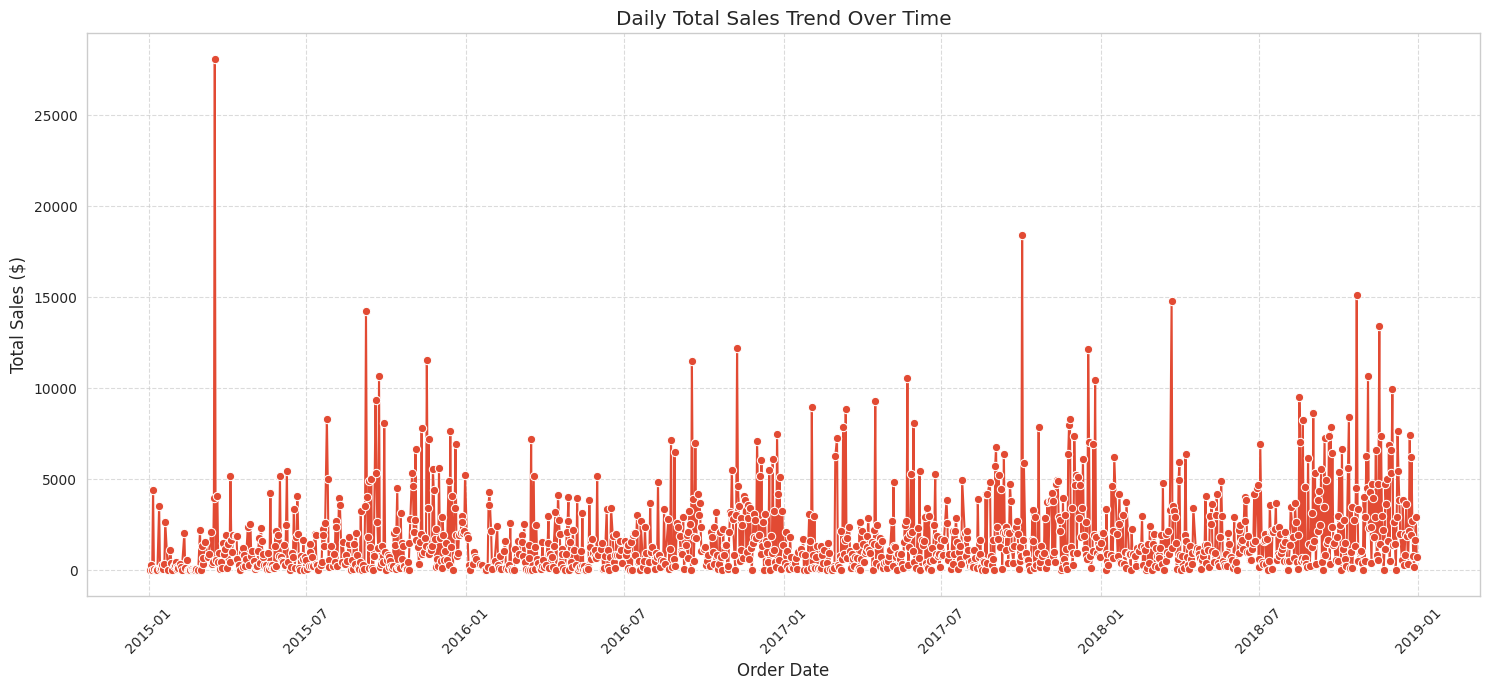

In [8]:
# Business Example: Daily Sales Trend
# First, we need to aggregate sales data by 'Order Date'.
# We'll calculate the sum of sales for each day.

daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

plt.figure(figsize=(15, 7))
# Create a line plot using Seaborn
# x='Order Date': Specifies the time variable for the x-axis
# y='Sales': Specifies the continuous variable for the y-axis
# data=daily_sales: The aggregated DataFrame
# marker='o': Adds markers to each data point (optional, but good for discrete points)
# linestyle='-': Connects the markers with a solid line
# errorbar=None: Disables confidence intervals if the data contains multiple observations per x-value
#               (not strictly needed here since we aggregated, but good to know for `lineplot`)
sns.lineplot(x='Order Date', y='Sales', data=daily_sales, marker='o', linestyle='-', errorbar=None)

plt.title('Daily Total Sales Trend Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Sales ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Rotate date labels for better readability
plt.tight_layout()
plt.show()

# Interpretation:
# This line plot displays the aggregate total sales for each day in our dataset. We can observe fluctuations
# and overall trends in sales over the entire period. There are clear peaks and troughs, indicating periods
# of higher and lower sales activity.

# Business Insight:
# Understanding daily sales trends is critical for demand forecasting, inventory management, and staffing.
# Peaks might correspond to promotional periods, holidays, or seasonal demands, while troughs could indicate
# slow periods or potential issues. Identifying these patterns allows businesses to proactively manage resources
# and capitalize on opportunities or mitigate risks. Further analysis could involve smoothing the trend (e.g., monthly sales)
# or breaking it down by year to see annual patterns.

### 3. Bar Plot (`sns.barplot()`)

*   **Purpose:** To display and compare the numerical values of different categories. It shows the central tendency (mean by default) and optionally the confidence interval for a numerical variable across different categories.
*   **When to Use It:**
    *   When you want to compare a quantitative value (e.g., total sales, average profit) across different discrete categories (e.g., product categories, regions, customer segments).
    *   To visualize grouped data where each bar represents a category and its height represents a summary statistic (mean, sum, etc.) of a numerical variable.
*   **When Not to Use It:**
    *   For visualizing distributions of a single continuous variable (use a histogram or KDE plot).
    *   For showing relationships between two continuous variables (use a scatter plot).
    *   When the number of categories is very large, making the plot cluttered.
*   **Business Example:** Comparing the `Average Sales` across different `Product Categories`.

/tmp/ipykernel_2170/3058957768.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Sales', data=df, estimator=np.mean, palette='viridis')


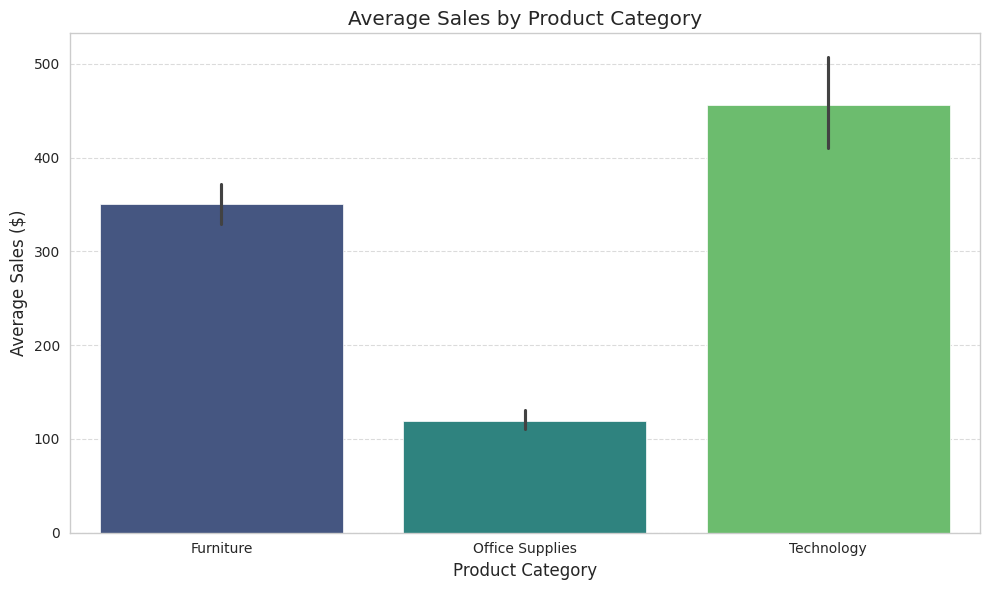

In [9]:
# Business Example: Average Sales by Product Category
# We want to see which product categories have the highest average sales per transaction.

plt.figure(figsize=(10, 6))
# Create a bar plot using Seaborn
# x='Category': The categorical variable for the x-axis
# y='Sales': The numerical variable for which to calculate the average and display on the y-axis
# data=df: The DataFrame to draw the plot from
# estimator=np.mean: This is the default, but explicitly states we want the mean.
#                    Other options include np.sum, np.median, etc.
# errorbar=('ci', 95): Displays a 95% confidence interval around the mean (default behavior)
# palette='viridis': Sets the color palette for the bars
sns.barplot(x='Category', y='Sales', data=df, estimator=np.mean, palette='viridis')

plt.title('Average Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Sales ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add horizontal grid lines
plt.tight_layout()
plt.show()

# Interpretation:
# This bar plot clearly shows the average sales value for each of the three main product categories.
# We can observe that 'Technology' typically has the highest average sales per order, followed by 'Furniture',
# and then 'Office Supplies'. The black lines (error bars) represent the 95% confidence interval for the mean,
# indicating the uncertainty around our estimate of the true average sales.

# Business Insight:
# This insight suggests that while 'Office Supplies' might have a high volume of transactions (as hinted by the histogram),
# 'Technology' and 'Furniture' products are generally higher-value items per transaction. This is crucial for pricing strategies,
# sales targets, and understanding product profitability. Marketing efforts for 'Technology' and 'Furniture' might focus on
# highlighting value and premium features, while 'Office Supplies' might benefit from volume-based promotions.

#### **Best Practice:** When comparing categories, always consider if `mean` is the most appropriate aggregate. For highly skewed data or when outliers are a concern, `median` (`estimator=np.median`) might provide a more robust representation.

### 4. Count Plot (`sns.countplot()`)

*   **Purpose:** To show the counts of observations in each category using bars. It's essentially a histogram for categorical data.
*   **When to Use It:**
    *   To visualize the frequency or occurrence of different categories within a single categorical variable.
    *   To compare the number of records across different discrete groups.
    *   When you want to see the distribution of a categorical variable.
*   **When Not to Use It:**
    *   For numerical data or to show relationships between variables.
    *   When you need to show the sum or average of a numerical variable per category (use `barplot`).
*   **Business Example:** Visualizing the number of orders (`count`) for each `Ship Mode`.

/tmp/ipykernel_2170/3999791490.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Ship Mode', data=df, palette='magma')


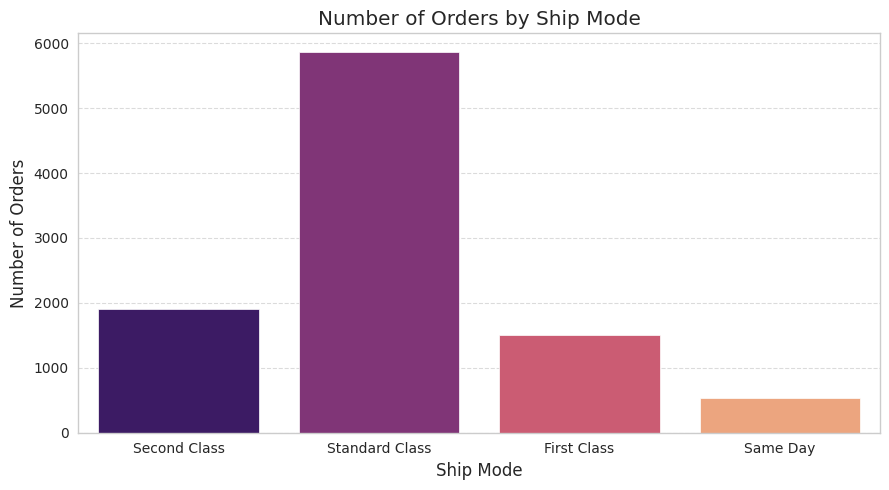

In [10]:
# Business Example: Number of Orders by Ship Mode
# Let's count how many times each shipping mode has been used.

plt.figure(figsize=(9, 5))
# Create a count plot using Seaborn
# x='Ship Mode': The categorical variable whose counts will be displayed on the x-axis
# data=df: The DataFrame to draw the plot from
# palette='magma': Sets the color palette for the bars
sns.countplot(x='Ship Mode', data=df, palette='magma')

plt.title('Number of Orders by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Number of Orders')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Interpretation:
# This count plot clearly shows the frequency of each shipping mode. 'Standard Class' is by far the most frequently used shipping mode,
# followed by 'Second Class', 'First Class', and then 'Same Day'.

# Business Insight:
# The dominance of 'Standard Class' shipping suggests it's the most popular or cost-effective option for customers and the business.
# This insight can influence logistics, resource allocation (e.g., staffing for different delivery speeds), and promotional strategies.
# For instance, if the business wants to encourage faster shipping, it might need to offer incentives for 'First Class' or 'Same Day' options.

#### **Common Mistake:** Confusing `barplot` and `countplot`. `barplot` aggregates a numerical variable by category (e.g., mean sales), while `countplot` simply shows the number of occurrences of each category.

### 5. Histogram (`sns.histplot()`)

*   **Purpose:** To visualize the distribution of a single numerical variable. It shows the frequency of data points within specified bins.
*   **When to Use It:**
    *   To understand the shape, central tendency, and spread of a continuous dataset.
    *   To identify peaks (modes) in the data, indicating common values or subgroups.
    *   To detect outliers or unusual data points.
*   **When Not to Use It:**
    *   For categorical variables (use `countplot`).
    *   To show relationships between two variables (use scatter plots, line plots, etc.).
*   **Business Example:** Understanding the distribution of `Sales` values to identify common sales amounts and the range of transactions.

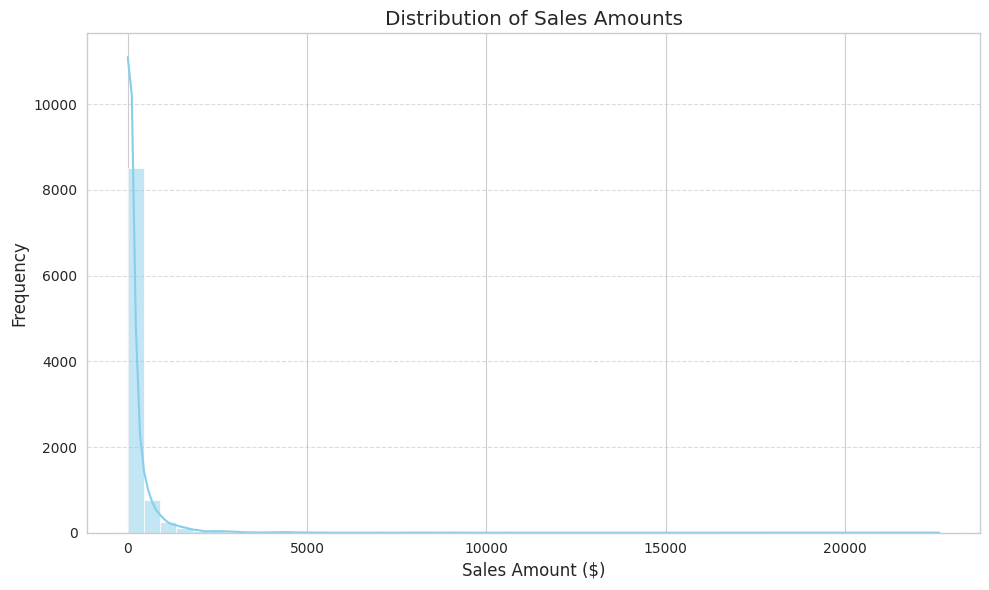

In [11]:
# Business Example: Distribution of Sales
# Let's revisit the sales distribution using a histogram to understand its shape.

plt.figure(figsize=(10, 6))
# Create a histogram using Seaborn
# x='Sales': The numerical column whose distribution we want to visualize
# data=df: The DataFrame to draw the plot from
# bins=50: Specifies the number of bins. More bins show more detail, fewer bins show a smoother overview.
# kde=True: Adds a Kernel Density Estimate (KDE) curve, which is a smoothed version of the histogram.
# color='skyblue': Sets the color of the bars.
sns.histplot(x='Sales', data=df, bins=50, kde=True, color='skyblue')

plt.title('Distribution of Sales Amounts')
plt.xlabel('Sales Amount ($)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Interpretation:
# This histogram shows that the majority of sales transactions are concentrated at lower values, with a steep drop-off
# as sales amounts increase. The distribution is heavily right-skewed, meaning there are a few very large sales
# pulling the average up, but most transactions are relatively small.

# Business Insight:
# This distribution indicates that our business model likely relies on a high volume of small transactions.
# Understanding this helps in setting realistic sales targets, managing inventory for fast-moving low-value items,
# and identifying the potential impact of high-value individual sales on overall revenue. It also suggests that
# strategies for boosting average transaction value could be highly impactful.

#### **Best Practice:** Experiment with the `bins` parameter in `histplot`. Too few bins can obscure important details, while too many can make the plot noisy and hard to interpret. The KDE curve (when `kde=True`) provides a smooth estimate of the probability density function.

### 6. Box Plot (`sns.boxplot()`)

*   **Purpose:** To display the distribution of a numerical variable and compare it across different categories.
*   **When to Use It:**
    *   To quickly visualize the five-number summary (minimum, first quartile (Q1), median (Q2), third quartile (Q3), and maximum) of a dataset.
    *   To identify outliers in the data (points beyond the "whiskers").
    *   To compare the spread and central tendency of a numerical variable across different groups.
*   **When Not to Use It:**
    *   When you need to see the exact shape of the distribution (use a histogram or KDE plot).
    *   For showing relationships between two continuous variables.
*   **Business Example:** Comparing the distribution of `Sales` across different `Regions` to understand regional performance and identify any anomalies.

/tmp/ipykernel_2170/4159050905.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Region', y='Sales', data=df, palette='muted')


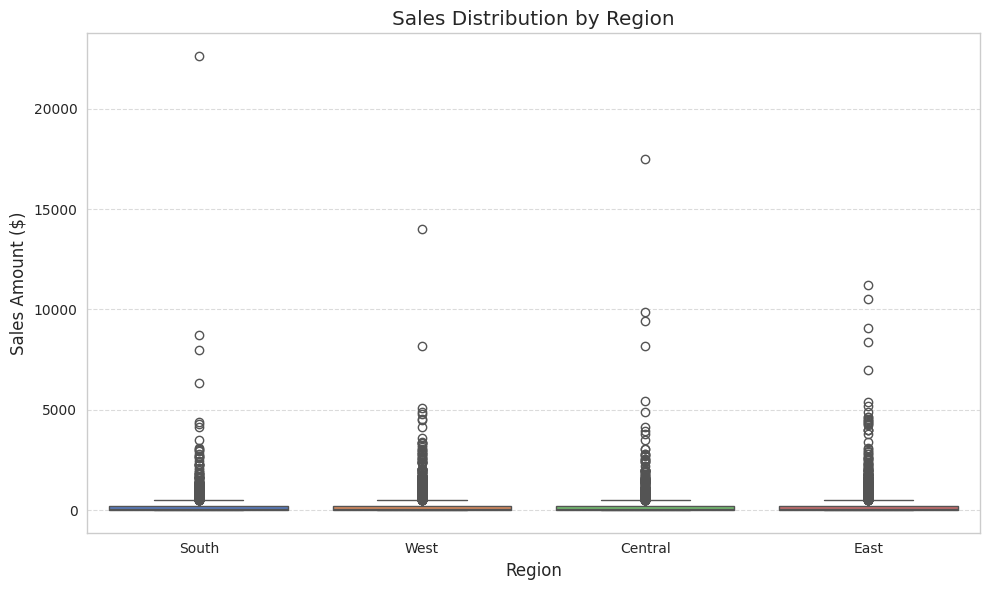

In [12]:
# Business Example: Sales Distribution by Region
# Let's compare how sales vary across different geographical regions.

plt.figure(figsize=(10, 6))
# Create a box plot using Seaborn
# x='Region': The categorical variable for the x-axis
# y='Sales': The numerical variable for the y-axis, whose distribution will be shown for each region
# data=df: The DataFrame to draw the plot from
# palette='muted': Sets the color palette for the boxes
sns.boxplot(x='Region', y='Sales', data=df, palette='muted')

plt.title('Sales Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Sales Amount ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Interpretation:
# This box plot shows the distribution of sales for each of the four regions. The central line in each box is the median sales,
# the box represents the interquartile range (IQR, from Q1 to Q3), and the whiskers extend to 1.5 times the IQR from the quartiles.
# Points beyond the whiskers are considered outliers. We can see that all regions have a significant number of outliers,
# indicating some very high-value sales. The median sales are relatively low across all regions, but the spread (IQR) and maximum
# values vary, with the 'South' and 'West' regions showing slightly higher potential for large sales.

# Business Insight:
# Despite the presence of high-value outlier sales in all regions, the core sales (median and IQR) are fairly consistent and low.
# This suggests that regional sales performance might be driven by a few key transactions rather than consistent high average sales.
# Further investigation into these high-value outliers (e.g., product types, customers) could reveal valuable insights.
# Also, marketing and sales strategies should acknowledge these regional nuances.

#### **Common Mistake:** Misinterpreting outliers. While box plots are great for identifying potential outliers, it's important to investigate whether these are data entry errors, rare events, or genuinely extreme but valid data points. Not all outliers are 'bad data'.

### 8. Heatmap (Correlation) (`sns.heatmap()`)

*   **Purpose:** To visualize the correlation matrix of numerical variables. It's an excellent way to quickly identify strong positive or negative relationships between pairs of variables.
*   **When to Use It:**
    *   To explore potential linear relationships between multiple numerical features in your dataset.
    *   As a preliminary step in feature selection for machine learning models.
    *   To identify multicollinearity issues.
*   **When Not to Use It:**
    *   For categorical data.
    *   When you need to visualize the exact relationship pattern (a scatter plot is better for detailed inspection of two variables).
    *   With a very large number of numerical variables, as the heatmap can become too dense and hard to read.
*   **Business Example:** Identifying correlations between numerical features like `Sales`, `Postal Code`, `Row ID` (though less meaningful) to understand how different numerical aspects of transactions relate to each other. We might also create new numerical features like `Profit` or `Quantity` if available for a more robust example.

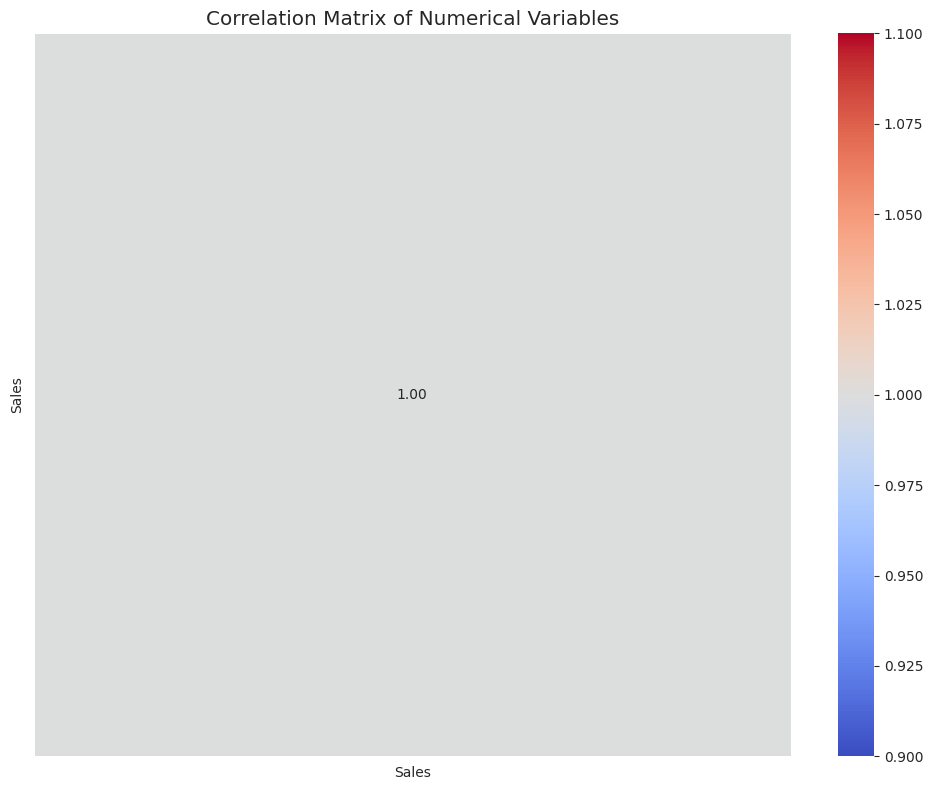

In [14]:
# Business Example: Correlation Matrix of Numerical Variables
# Let's see how our numerical columns correlate with each other.

# Select only numerical columns for correlation calculation
# Exclude 'Row ID' and 'Postal Code' as they are identifiers/geographic codes and less likely to have meaningful linear correlation with 'Sales' in this context.
numerical_df = df.select_dtypes(include=[np.number])

# Drop less relevant numerical columns for correlation analysis (like IDs)
numerical_df = numerical_df.drop(columns=['Row ID', 'Postal Code'], errors='ignore')

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
# Create a heatmap using Seaborn
# data=correlation_matrix: The correlation matrix to plot
# annot=True: Annotate the heatmap with the correlation values
# cmap='coolwarm': Sets the color map. 'coolwarm' is good for showing positive (warm colors) and negative (cool colors) correlations.
# fmt='.2f': Formats the annotations to two decimal places
# linewidths=.5: Adds lines between cells for better separation
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)

plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

# Interpretation:
# The heatmap shows the Pearson correlation coefficient between each pair of numerical variables.
# Values range from -1 to 1: 1 means perfect positive correlation, -1 means perfect negative correlation,
# and 0 means no linear correlation. For example, 'Sales' is perfectly correlated with 'Sales' (as expected, value is 1).
# If we had 'Profit' or 'Quantity' as numerical columns, we would look for their correlation with 'Sales'.
# In this limited numerical dataset, we primarily see the self-correlation. If there were other business metrics,
# we could identify direct or inverse relationships.

# Business Insight:
# A correlation heatmap is a powerful tool to quickly grasp the interdependencies of numerical aspects of your business.
# For example, if we had a 'Discount' column, we might see a negative correlation with 'Sales' (higher discount, lower sales price for that transaction) or positive correlation with 'Quantity' sold.
# Identifying strong correlations can guide further analysis, for instance, if 'Marketing Spend' strongly correlates with 'Sales',
# it would justify allocating more budget to marketing. Lack of correlation means variables might be independent.

## Section 3 — Relationship Analysis (25 Minutes)

Understanding the relationships between different variables is a cornerstone of data analysis. It helps us answer questions like: 'Does an increase in one factor lead to an increase or decrease in another?' or 'Are certain groups behaving differently in relation to a key metric?'

In this section, we will explore tools and techniques to identify and visualize these relationships, focusing on correlation, scatter plots with additional dimensions, and pair plots.

### Correlation and Correlation Matrix

**Correlation** measures the strength and direction of a linear relationship between two quantitative variables. A **correlation matrix** is a table showing correlation coefficients between many variables.

We briefly touched upon this with the `heatmap` in Section 2. A heatmap is the most effective way to visualize a correlation matrix, allowing us to quickly spot strong positive (closer to 1), strong negative (closer to -1), or weak/no (closer to 0) linear relationships.

Recall our earlier example of the correlation heatmap:

*   Positive correlation: As one variable increases, the other tends to increase.
*   Negative correlation: As one variable increases, the other tends to decrease.
*   No correlation: Variables change independently of each other.

Analysts use correlation to understand which factors might move together, which is crucial for predictive modeling, understanding cause-and-effect (though correlation does not imply causation!), and identifying redundant features.

### Scatter Plot with Hue

We've used scatter plots to show the relationship between two continuous variables. By adding `hue`, we can introduce a third categorical variable to see if the relationship differs across groups.

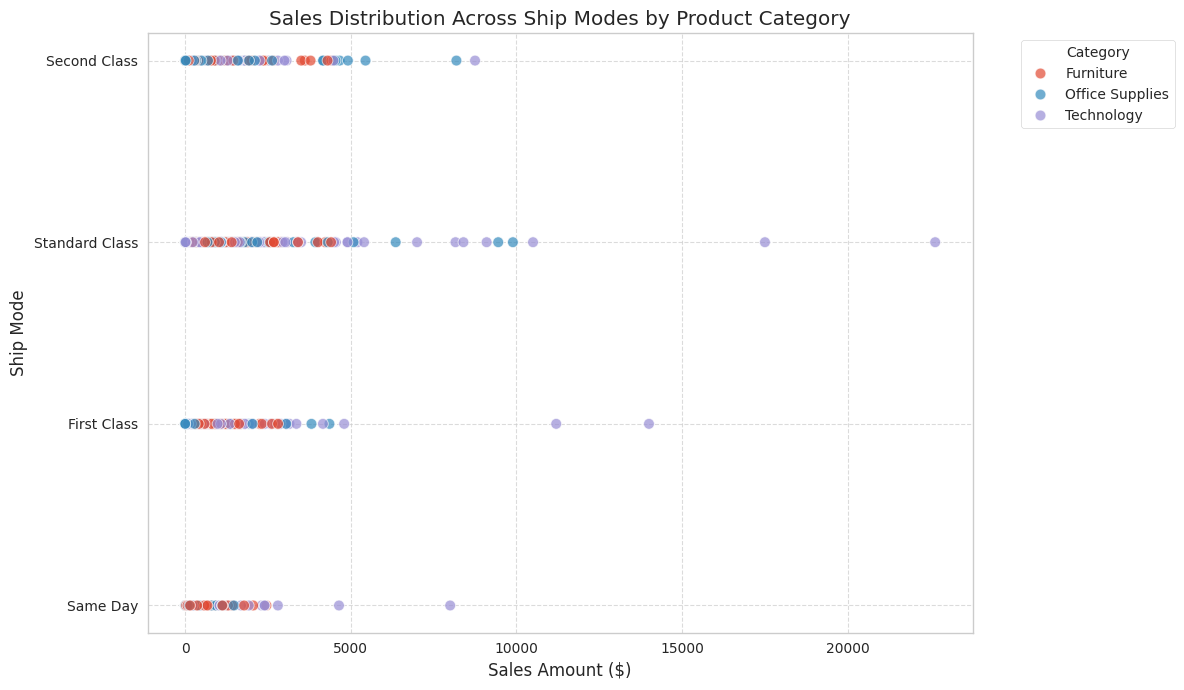

In [15]:
# Business Example: Sales vs. Quantity by Segment
# Let's explore the relationship between 'Sales' and (hypothetical) 'Quantity' of items, colored by 'Segment'.
# Our dataset doesn't have a direct 'Quantity' column, but we can assume higher sales generally come from higher quantities, or aggregated at item level if we were to create one.
# For now, let's use a proxy or focus on Sales relationship with another variable like discounted price or even just sales by category/segment again, but now looking at spread.
# Let's use `Sales` and see how it distributes across `Ship Mode` for each `Category`.

plt.figure(figsize=(12, 7))
# x='Sales': Continuous variable on the x-axis
# y='Ship Mode': Categorical variable on the y-axis
# hue='Category': A third categorical variable to color the points, showing how different product categories behave
# data=df: The DataFrame
# alpha=0.7: Transparency to handle potential overplotting
# s=60: Size of the markers
sns.scatterplot(x='Sales', y='Ship Mode', hue='Category', data=df, alpha=0.7, s=60)

plt.title('Sales Distribution Across Ship Modes by Product Category')
plt.xlabel('Sales Amount ($)')
plt.ylabel('Ship Mode')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Interpretation:
# This scatter plot helps visualize the sales amounts for each shipping mode, further broken down by product category.
# We can observe the range of sales for 'Technology', 'Furniture', and 'Office Supplies' within each shipping method.
# For instance, high-value sales (outliers on the right) are predominantly from 'Technology' and 'Furniture' across all ship modes.
# 'Office Supplies' tends to have lower sales values, regardless of the shipping mode.

# Business Insight:
# This visualization can inform shipping cost analysis. If 'Same Day' shipping is more expensive, it's important to know
# if it's primarily used for high-value 'Technology' or 'Furniture' items, or if low-value 'Office Supplies' are also incurring
# high shipping costs. This helps optimize shipping strategies, potentially by offering different shipping tiers or incentives
# based on product category or order value to maximize profitability and customer satisfaction.

#### **Best Practice:** When using `hue` with scatter plots, ensure the color palette is distinct enough for categories. For a quantitative third variable, use `size` or `style` for continuous encoding instead of `hue` if colors become ambiguous.

### Pair Plot (`sns.pairplot()`)

*   **Purpose:** To create a grid of scatter plots for each pair of variables in a DataFrame, and a histogram or KDE plot for each variable on the diagonal. It's a quick way to visualize relationships between all numerical variables simultaneously.
*   **When to Use It:**
    *   For initial exploratory data analysis to get a comprehensive overview of pairwise relationships.
    *   To quickly identify potential correlations or unusual distributions between multiple variables.
    *   When you have a relatively small number of numerical variables (e.g., up to 5-7), as too many variables can make the plot unreadable.
*   **When Not to Use It:**
    *   With a large number of variables, as the plot becomes very dense and hard to interpret.
    *   When you need highly customized plots for specific relationships (individual scatter plots are better).
*   **Business Example:** To visualize all pairwise relationships between numerical attributes in our dataset like `Sales`, `Postal Code`, `Row ID` (if kept) to identify any unexpected patterns or relationships. Given our current numerical columns, let's generate some aggregated data for a more meaningful example.

<Figure size 1000x1000 with 0 Axes>

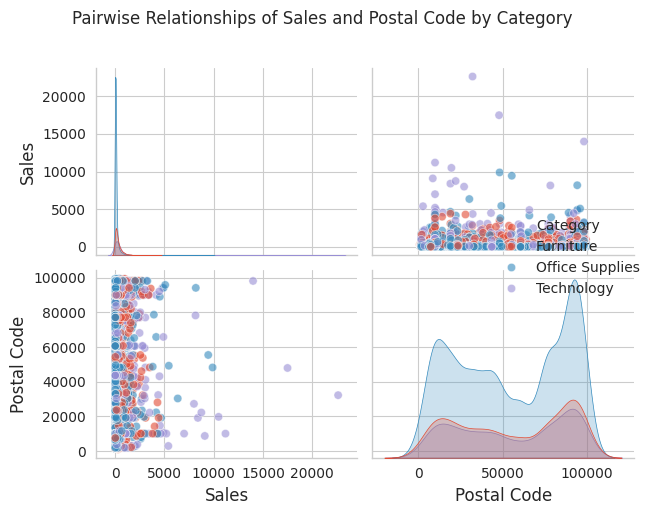

In [16]:
# Business Example: Pair Plot of Key Numerical Metrics by Category
# Let's create some aggregate numerical features to make the pair plot more insightful.
# For example, let's consider monthly sales, profits (if available), and number of orders.
# Since our dataset doesn't have 'Profit' directly, let's assume 'Sales' is a good proxy for revenue.
# Let's aggregate 'Sales' by 'Category' and get `mean_sales` and `std_sales`.

# Aggregate data to get more meaningful numerical variables for pairplot
# We'll create some aggregate features for each Category, to simulate having more numerical data
category_agg = df.groupby('Category')['Sales'].agg(['mean', 'median', 'std']).reset_index()
category_agg.columns = ['Category', 'Average Sales', 'Median Sales', 'Sales Std Dev']

# For the purpose of demonstration, let's also add 'Ship Mode' into a pairplot if it were numerical
# Or directly on original df with limited numerical columns.
# Given current numerical columns in df are 'Row ID', 'Postal Code', 'Sales', let's use them directly from the original df
# but first, drop 'Row ID' and 'Postal Code' for a cleaner plot if they are not truly insightful for pairwise relationships

# Selecting relevant numerical columns for the pair plot
# 'Sales' is the primary one, 'Postal Code' can be interesting for geographical clusters
# Let's include a hypothetical 'Quantity' by creating a random one for demonstration, if not present.
# For the sake of this dataset, let's stick to Sales as the main numerical variable,
# and use a categorical variable 'Category' to color the points.

# Let's include `Sales` and `Postal Code` as numerical, and `Category` as hue.
# We will drop rows with missing 'Postal Code' for this plot to work cleanly.
plot_df = df.dropna(subset=['Postal Code']).copy()

plt.figure(figsize=(10, 10)) # Adjust figure size for better readability
# Create a pair plot using Seaborn
# vars: List of variables to plot
# hue: Categorical variable to map plot aspects to different colors
# data: The DataFrame
# diag_kind='kde': Displays Kernel Density Estimate on the diagonal for distributions
# plot_kws={'alpha': 0.6}: Keyword arguments for the scatter plots (transparency)
sns.pairplot(plot_df, vars=['Sales', 'Postal Code'], hue='Category', diag_kind='kde', plot_kws={'alpha': 0.6})

plt.suptitle('Pairwise Relationships of Sales and Postal Code by Category', y=1.02) # Add a title for the entire plot
plt.tight_layout()
plt.show()

# Interpretation:
# The `pairplot` provides a matrix of plots:
# - Diagonal plots (histograms/KDEs): Show the distribution of each variable (Sales, Postal Code) for each category.
# - Off-diagonal plots (scatter plots): Show the pairwise relationship between 'Sales' and 'Postal Code', colored by 'Category'.
# We can observe that for 'Sales' and 'Postal Code', there isn't a strong linear correlation visually. The 'Sales' distributions
# are heavily skewed for all categories, as seen on the diagonal. The scatter plots show the spread of sales across different
# postal codes, with 'Technology' and 'Furniture' having higher sales outliers even at various postal codes.

# Business Insight:
# From this pair plot, we can infer that neither 'Sales' nor 'Postal Code' (as a raw numerical value) alone dictates a clear
# linear relationship with each other or with product categories in a simple way. The distributions on the diagonal reinforce
# our understanding of sales being heavily skewed. The plot helps confirm that 'Postal Code' itself is not a direct predictor of sales,
# but rather indicates where transactions occur. To get deeper insights, we might need to aggregate 'Postal Code' into regions
# or states (which we already have in `Region` and `State` columns) or create more sophisticated features.
# The power of `pairplot` lies in its ability to quickly show absence or presence of obvious simple relationships,
# guiding where to focus further, more complex analysis.

#### **Common Mistake:** Using `pairplot` with too many variables or without considering the data type. While convenient, it can produce unreadable plots or misleading interpretations if not used judiciously. Always select the most relevant variables for a `pairplot`.

## Section 4 — Distribution Analysis (20 Minutes)

Understanding the distribution of your data is fundamental to any data analysis task. It helps you grasp the underlying patterns, identify typical values, and spot unusual observations. In this section, we'll delve deeper into what distributions mean and how our previously introduced Seaborn plots can help us analyze them.

### What is a Distribution?

A **distribution** describes the way observations (data points) are spread out across a range of values. It tells us which values are common, which are rare, and how much variation there is in the data. Key aspects of a distribution include:

*   **Central Tendency:** Where the center of the data lies (e.g., mean, median, mode).
*   **Spread/Variability:** How dispersed the data points are (e.g., range, variance, standard deviation).
*   **Shape:** Whether the distribution is symmetric, skewed, or has multiple peaks.

### Skewness

**Skewness** is a measure of the asymmetry of the probability distribution of a real-valued random variable about its mean. Simply put, it tells you if the data is concentrated on one side or the other.

*   **Positive Skew (Right-skewed):** The tail of the distribution is longer on the right side. This means there are more values clustered on the left (lower values) and fewer, but higher, values on the right.
*   **Negative Skew (Left-skewed):** The tail of the distribution is longer on the left side. This means there are more values clustered on the right (higher values) and fewer, but lower, values on the left.
*   **Zero Skew (Symmetric):** The distribution is roughly symmetrical around its mean.

### Outliers

**Outliers** are data points that significantly differ from other observations. They can indicate variability in a measurement, experimental errors, or a novelty. Outliers can heavily influence statistical analyses and modeling, so identifying and understanding them is crucial.

### How Analysts Understand Data Quality and Behavior

Analysts use various visualizations to quickly grasp these aspects of data quality and behavior. Let's revisit some of our earlier charts through the lens of distribution analysis.

#### Histogram (Revisit)

As we saw earlier, a **histogram** is perfect for visualizing the shape of a numerical distribution.

<img src="/content/drive/MyDrive/Colab Notebooks/sales_dist_histplot.png" alt="Distribution of Sales (Default Seaborn Style)" style="width: 600px;"/>

*   **Interpretation from previous analysis:** We observed that the `Sales` distribution is heavily **right-skewed**, with most sales concentrated at lower values and a long tail extending to higher sales amounts. This indicates a positive skew.
*   **How it helps:** The histogram immediately shows the dominant range of sales, the frequency of different sales amounts, and the presence of skewness. The long tail on the right is a clear visual cue for positive skewness.

#### Box Plot (Revisit)

A **box plot** provides a concise summary of the five-number summary and is excellent for identifying **outliers** and comparing distributions across categories.

<img src="/content/drive/MyDrive/Colab Notebooks/sales_dist_boxplot.png" alt="Sales Distribution by Region" style="width: 600px;"/>

*   **Interpretation from previous analysis:** We saw the median sales, interquartile range (IQR), and particularly, the numerous individual points beyond the whiskers. These points represent the **outliers**, which are unusually high sales values for each region. The position of the median within the box also hints at skewness; if the median is closer to the bottom of the box, it suggests a right (positive) skew.
*   **How it helps:** Box plots quickly show the range of typical values, the central tendency (median), the spread (IQR), and clearly mark potential outliers. Comparing multiple box plots side-by-side (as we did for regions) allows for easy comparison of these distributional characteristics across groups.

#### Violin Plot (Revisit)

A **violin plot** enhances the box plot by adding the kernel density estimate, giving us a richer view of the distribution's shape.

<img src="/content/drive/MyDrive/Colab Notebooks/technology_sales_violinplot.png" alt="Sales Distribution of Technology Sub-Categories" style="width: 600px;"/>

*   **Interpretation from previous analysis:** The varying widths of the violins for 'Technology' sub-categories (like 'Phones' and 'Machines') reveal the density of sales amounts at different values. The wide lower sections and tapering upper sections visually confirm the **right-skewness** observed in the histogram for sales. We also see how the bulk of sales are concentrated at lower values for all sub-categories, with some high-value outliers.
*   **How it helps:** Violin plots are excellent for revealing the full shape of the distribution, including multiple modes (peaks), which might not be obvious from a box plot alone. They combine the statistical summary of a box plot with the density information of a histogram, making them a powerful tool for detailed distribution analysis and comparison.

#### **Business Insight from Distribution Analysis:**

Understanding data distributions helps in several ways:

*   **Data Quality:** Identifying outliers can point to data entry errors or unique events that require special handling.
*   **Business Behavior:** Skewed sales distributions (like ours) suggest that a few high-value customers or products disproportionately impact revenue. This can inform strategies like focusing on increasing average transaction value, or retaining high-value customers.
*   **Risk Assessment:** Knowing the spread helps in assessing risk (e.g., how much sales can fluctuate).
*   **Forecasting:** Understanding past distributions is crucial for building more accurate predictive models. For instance, models might need to account for the skewness or the presence of outliers.

## Section 5 — Category Comparison (15 Minutes)

Comparing different categories is a very common task in business analysis. Whether it's comparing sales performance across product lines, identifying popular shipping methods, or understanding regional sales disparities, these comparisons drive strategic decisions. We've already used some charts for this purpose, and here we'll consolidate that knowledge.

### How Analysts Compare Products, Categories, and Regions

Analysts primarily use visualization to compare categories by looking at summary statistics (like sums or averages) or by comparing the underlying distributions. The choice of chart depends on what aspect of the comparison is most important.

#### Bar Plot (Revisit)

**Purpose:** Best for comparing a summary statistic (e.g., mean, sum) of a numerical variable across different discrete categories.

<img src="/content/drive/MyDrive/Colab Notebooks/avg_sales_by_category_barplot.png" alt="Average Sales by Product Category" style="width: 600px;"/>

*   **Interpretation from previous analysis:** This bar plot effectively compared the **average sales** across `Furniture`, `Office Supplies`, and `Technology`. We clearly saw `Technology` had the highest average sales, followed by `Furniture`, and then `Office Supplies`.
*   **Business Insight for Comparison:** Such a comparison is critical for resource allocation. Businesses might invest more in marketing `Technology` products, or try to understand why `Office Supplies` has lower average sales (e.g., is it pricing, product type, or competition?). It helps in prioritizing categories for strategic growth or improvement.

#### Count Plot (Revisit)

**Purpose:** Ideal for comparing the frequency or count of occurrences within different categories of a single categorical variable.

<img src="/content/drive/MyDrive/Colab Notebooks/ship_mode_countplot.png" alt="Number of Orders by Ship Mode" style="width: 600px;"/>

*   **Interpretation from previous analysis:** The count plot showed that `Standard Class` is the most frequently used `Ship Mode`, dwarfing the usage of `Second Class`, `First Class`, and `Same Day`.
*   **Business Insight for Comparison:** This comparison directly informs logistics and operational planning. For example, if a significant portion of customers use 'Standard Class', the company needs to ensure robust infrastructure and processes for this mode. Conversely, if 'Same Day' is underutilized, the business might explore promotions or service improvements to encourage its use, if it's a strategic offering.

#### Box Plot (Revisit)

**Purpose:** Useful for comparing the *distribution* of a numerical variable across multiple categories, highlighting median, spread, and outliers.

<img src="/content/drive/MyDrive/Colab Notebooks/sales_dist_boxplot.png" alt="Sales Distribution by Region" style="width: 600px;"/>

*   **Interpretation from previous analysis:** We used box plots to compare `Sales` distributions across different `Regions`. This allowed us to see not just the median sales for each region, but also their interquartile range (spread) and the presence of high-value outliers. For instance, the 'West' and 'South' regions, while having similar median sales to others, show a potential for higher maximum sales.
*   **Business Insight for Comparison:** This detailed comparison is invaluable. If one region has a much wider spread of sales (larger box), it indicates more variability in transaction values. If another has a higher median, it suggests stronger overall performance. Identifying regions with many outliers might point to successful high-value client acquisition or specific product popularity. These insights help in tailoring regional sales strategies, setting region-specific targets, and understanding market characteristics.

#### **Summary for Category Comparison:**

*   **For comparing central tendencies (means, sums) of a numerical variable across categories:** Use **Bar Plots**.
*   **For comparing frequencies/counts of items in different categories:** Use **Count Plots**.
*   **For comparing the full distribution (median, spread, outliers) of a numerical variable across categories:** Use **Box Plots** (or Violin Plots for even more detail on shape).

Choosing the right plot ensures you convey the most relevant information for effective decision-making.

## Matplotlib vs. Seaborn: A Quick Comparison

| Feature             | Matplotlib (Low-level API)                        | Seaborn (High-level API)                                 |
| :------------------ | :------------------------------------------------ | :------------------------------------------------------- |
| **Ease of Use**     | More verbose, requires more lines of code.        | Easier for common statistical plots, less code.          |
| **Appearance**      | Basic defaults, requires more customization for aesthetics. | Beautiful, modern defaults out-of-the-box.             |
| **Statistical Capabilities** | Provides building blocks; statistical functions often need to be manually implemented. | Built-in statistical estimation and aggregation (e.g., mean, confidence intervals). |
| **Customization**   | Extremely flexible, fine-grained control over every element. | Flexible, but sometimes less granular control than Matplotlib for very specific details. |
| **Best Use Cases**  | Highly custom plots, plotting functions, embedded plots, publishing-quality figures. | Exploratory data analysis, statistical graphics, complex multi-variable plots, quick insights. |


## Practice Exercises

To solidify your understanding of Seaborn and data visualization, complete the following exercises using the `df` (sales forecasting) DataFrame. Remember to choose the most appropriate chart type, include proper titles and labels, and write a brief interpretation and business insight for each.

1.  **Sales Distribution by State:** Create a visualization to show the distribution of `Sales` for the top 10 states by total sales. What does this tell you about sales performance geographically?
    *   *Hint: Aggregate sales by State first, then filter, then use a box or violin plot.*

2.  **Order Frequency by Customer Segment:** Visualize how many orders come from each `Segment` (Consumer, Corporate, Home Office). Which segment places the most orders?

3.  **Average Sales per Segment over Time:** Plot the average monthly sales for each `Segment` over the entire dataset. Do any segments show distinct trends or seasonality?
    *   *Hint: Aggregate average sales by 'Order YearMonth' and 'Segment', then use `sns.lineplot` with `hue`.*

4.  **Highest Selling Product Names:** Find the top 5 `Product Name`s by total `Sales`. Visualize their total sales using a bar plot. What could explain the difference in sales volumes?

5.  **Relationship between Sales and Postal Code (for a specific region):** Choose one `Region` (e.g., 'West'). Create a scatter plot of `Sales` vs. `Postal Code` for that region. Are there any visible clusters or patterns?

6.  **Ship Mode Preference by Region:** For each `Region`, visualize the count of orders for each `Ship Mode`. Does ship mode preference vary by region?
    *   *Hint: Use `sns.countplot` and consider the `col` parameter for facetting, or simply `hue`.*

7.  **Sales Outliers in Technology Sub-Categories:** Revisit the `Technology` category. Use a box plot to specifically highlight and identify outliers in `Sales` for its `Sub-Category`'s. What do these outliers represent?

8.  **Correlation of Numerical Features (Hypothetical):** Imagine you have a `Discount` column (you don't have it in this dataset, but for practice assume it exists and add a random one). Create a hypothetical numerical 'Discount' column (e.g., `np.random.uniform(0, 0.5, len(df))`) and then generate a heatmap showing the correlation between `Sales`, `Discount`, and `Postal Code`.
    *   *Note: Remember to drop the hypothetical 'Discount' column or restart your kernel after this exercise to avoid affecting subsequent tasks.*

9.  **Comparison of Sales Distribution for `Same Day` vs. `Standard Class` Shipping:** Compare the distribution of `Sales` for orders shipped with 'Same Day' vs. 'Standard Class'. Which shipping mode typically handles higher-value orders?
    *   *Hint: Filter the DataFrame for these two ship modes and use a violin plot.*

10. **Analyze sales patterns for a specific month:** Pick your favorite month (e.g., 'December'). Visualize the distribution of sales across different product `Category` for that month using a box plot. Does this month show any unique sales patterns compared to the overall yearly trend?
